## 485-DL Final Project

In [13]:
# ============================================================
# Section 1: Data Loading & Preprocessing
# MSDS 485 Final Project — Max Chalekson
# ============================================================

import re
import pandas as pd
from datasets import load_dataset
from langdetect import detect, LangDetectException
from tqdm import tqdm

# ── 1a. Sentiment140 ─────────────────────────────────────────

S140_PATH = '/Users/maxchalekson/Northwestern University/Spring-2026/MSDS-453-DL/Final-Project/FP-DataSources/training.1600000.processed.noemoticon.csv'
S140_COLS = ["target", "ids", "date", "flag", "user", "text"]

def load_sentiment140(path: str, n_per_class: int = 50_000, seed: int = 42) -> pd.DataFrame:
    """
    Load a stratified sample from Sentiment140.

    The file is ordered: first 800k rows are negative (0),
    last 800k are positive (4). Reading the whole file and then
    sampling stratified avoids the ordering bias.

    Returns a DataFrame with columns: text, label (0 = neg, 1 = pos)
    """
    df = pd.read_csv(path, header=None, names=S140_COLS,
                     encoding="latin-1")

    # Recode: 0 → 0 (negative), 4 → 1 (positive)
    df["label"] = (df["target"] == 4).astype(int)

    neg = df[df["label"] == 0].sample(n=n_per_class, random_state=seed)
    pos = df[df["label"] == 1].sample(n=n_per_class, random_state=seed)
    sampled = pd.concat([neg, pos]).sample(frac=1, random_state=seed).reset_index(drop=True)

    return sampled[["text", "label"]]


# ── 1b. Bluesky ──────────────────────────────────────────────

def is_english(text: str) -> bool:
    """Return True if langdetect identifies the text as English."""
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False


def load_bluesky(n: int = 100_000, seed: int = 42) -> pd.DataFrame:
    """
    Load a sample from the withalim/bluesky-posts HuggingFace dataset,
    filtered to English-only posts.

    Uses a 3x buffer to avoid scanning all 7.8M rows — samples 3*n rows
    first, filters to English, then takes n. At ~60% English retention
    a 3x buffer comfortably yields the target n.

    Returns a DataFrame with column: text
    """
    ds = load_dataset("withalim/bluesky-posts", split="train")
    df = ds.to_pandas()[["text"]].dropna()
    print(f"Bluesky raw rows: {len(df)}")

    # 3x buffer — filters ~300k rows instead of 7.8M
    buffer = df.sample(n=min(n * 3, len(df)), random_state=seed).reset_index(drop=True)
    print(f"Filtering language on {len(buffer):,} sampled rows (~3 mins)...")

    results = []
    for text in tqdm(buffer["text"], desc="Detecting language", ncols=80):
        results.append(is_english(text))
    buffer["is_en"] = results

    english = buffer[buffer["is_en"]].drop(columns="is_en").reset_index(drop=True)
    print(f"English rows after filtering: {len(english):,}")

    sampled = english.sample(n=min(n, len(english)), random_state=seed).reset_index(drop=True)
    return sampled


# ── 1c. Text cleaning ────────────────────────────────────────

def clean_tweet(text: str) -> str:
    """
    Minimal cleaning for short social media text.
    Preserves signal for TF-IDF, Doc2Vec, and SBERT representations.

      - Lowercase
      - Remove URLs
      - Remove @mentions
      - Remove # symbol but keep hashtag word
      - Collapse whitespace
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Apply cleaning and drop empty rows."""
    df = df.copy()
    df["text_clean"] = df["text"].astype(str).apply(clean_tweet)
    df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
    return df


# ── 1d. Run it ───────────────────────────────────────────────

if __name__ == "__main__":
    print("Loading Sentiment140...")
    s140 = load_sentiment140(S140_PATH, n_per_class=50_000)
    s140 = preprocess(s140)
    print(f"Sentiment140: {len(s140):,} rows | label dist:\n{s140['label'].value_counts()}")
    print(s140[["text_clean", "label"]].head(3))

    print("\nLoading Bluesky...")
    bsky = load_bluesky(n=100_000)
    bsky = preprocess(bsky)
    print(f"Bluesky: {len(bsky):,} rows")
    print(bsky["text_clean"].head(3))

    # ── Save filtered corpora so you never rerun the slow steps ──
    s140.to_csv("s140_clean.csv", index=False)
    bsky.to_csv("bsky_clean.csv", index=False)
    print("\nSaved: s140_clean.csv, bsky_clean.csv")

    # ── Save filtered corpora so you never rerun the slow steps ──
    s140.to_csv("s140_clean.csv", index=False)
    bsky.to_csv("bsky_clean.csv", index=False)
    print("\nSaved: s140_clean.csv, bsky_clean.csv")

Loading Sentiment140...
Sentiment140: 99,822 rows | label dist:
label
1    49916
0    49906
Name: count, dtype: int64
               text_clean  label
0          that's awesome      1
1            yes... i am!      1
2  n my bed aaallll alone      0

Loading Bluesky...
Bluesky raw rows: 7877660
Filtering language on 300,000 sampled rows (~3 mins)...


Detecting language: 100%|██████████████| 300000/300000 [05:42<00:00, 874.88it/s]


English rows after filtering: 168,567
Bluesky: 99,556 rows
0      if it's silly and has cannibals i'm enjoying it
1        i've gone right off gregg's hot sausage roll.
2    new video 📽️🚨 fpl in this video, i discuss you...
Name: text_clean, dtype: object

Saved: s140_clean.csv, bsky_clean.csv

Saved: s140_clean.csv, bsky_clean.csv


Loading cleaned corpora...
Sentiment140 rows: 99,822
Bluesky rows: 99,556
Vectorizing Sentiment140...
Sentiment140 TF-IDF shape: (99822, 15529)
Vectorizing Bluesky...
Bluesky TF-IDF shape: (99556, 20000)

Running K-means sweep on Sentiment140...
k=2: silhouette=0.0035
k=3: silhouette=0.0042
k=4: silhouette=0.0046
k=5: silhouette=0.0052
k=6: silhouette=0.0054
k=7: silhouette=0.0059
k=8: silhouette=0.0064
k=9: silhouette=0.0070
k=10: silhouette=0.0070

Running K-means sweep on Bluesky...
k=2: silhouette=0.0027
k=3: silhouette=0.0036
k=4: silhouette=0.0041
k=5: silhouette=0.0053
k=6: silhouette=0.0054
k=7: silhouette=0.0059
k=8: silhouette=0.0062
k=9: silhouette=0.0076
k=10: silhouette=0.0077


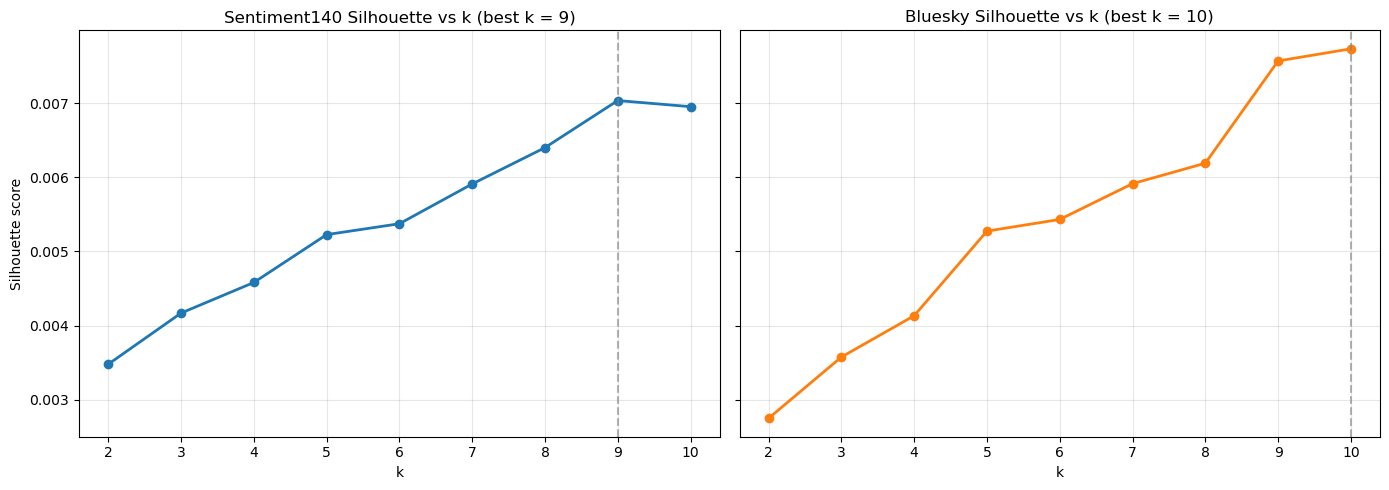


Cluster quality summary:
      corpus  best_k  silhouette     ARI      NMI
Sentiment140       9    0.007036 0.00561 0.017363
     Bluesky      10    0.007734     NaN      NaN


In [14]:
# ============================================================
# Section 2: TF-IDF Vectorization + K-means Clustering
# ============================================================

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

RANDOM_STATE = 42
TFIDF_PARAMS = {
    "max_features": 20_000,
    "min_df": 3,
    "max_df": 0.95,
    "sublinear_tf": True,
}


def load_clean_corpus(path: str, label_col: str | None = None) -> pd.DataFrame:
    """Load a cleaned corpus and drop empty rows."""
    df = pd.read_csv(path)
    required_cols = ["text_clean"] + ([label_col] if label_col is not None else [])
    df = df.dropna(subset=required_cols).reset_index(drop=True)
    df["text_clean"] = df["text_clean"].astype(str)
    if label_col is not None:
        df[label_col] = df[label_col].astype(int)
    return df


def vectorize_text(texts: pd.Series):
    """Fit TF-IDF on a corpus and return the sparse matrix plus the vectorizer."""
    vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
    matrix = vectorizer.fit_transform(texts)
    return matrix, vectorizer


def sweep_kmeans_silhouette(X, k_values=range(2, 11), sample_size=10_000):
    """Fit K-means across k values and score each clustering with silhouette."""
    results = []
    best_model = None
    best_k = None
    best_score = -1.0

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels, sample_size=sample_size, random_state=RANDOM_STATE)
        results.append({"k": k, "silhouette": score})
        print(f"k={k}: silhouette={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_model = model

    results_df = pd.DataFrame(results)
    return results_df, best_k, best_score, best_model


print("Loading cleaned corpora...")
s140_clean = load_clean_corpus("s140_clean.csv", label_col="label")
bsky_clean = load_clean_corpus("bsky_clean.csv")

print(f"Sentiment140 rows: {len(s140_clean):,}")
print(f"Bluesky rows: {len(bsky_clean):,}")

print("Vectorizing Sentiment140...")
X_s140, s140_vectorizer = vectorize_text(s140_clean["text_clean"])
print(f"Sentiment140 TF-IDF shape: {X_s140.shape}")

print("Vectorizing Bluesky...")
X_bsky, bsky_vectorizer = vectorize_text(bsky_clean["text_clean"])
print(f"Bluesky TF-IDF shape: {X_bsky.shape}")

print("\nRunning K-means sweep on Sentiment140...")
s140_results, s140_best_k, s140_best_silhouette, s140_best_model = sweep_kmeans_silhouette(X_s140)

print("\nRunning K-means sweep on Bluesky...")
bsky_results, bsky_best_k, bsky_best_silhouette, bsky_best_model = sweep_kmeans_silhouette(X_bsky)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(s140_results["k"], s140_results["silhouette"], marker="o", linewidth=2)
axes[0].axvline(s140_best_k, color="gray", linestyle="--", alpha=0.6)
axes[0].set_title(f"Sentiment140 Silhouette vs k (best k = {s140_best_k})")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette score")
axes[0].grid(True, alpha=0.3)

axes[1].plot(bsky_results["k"], bsky_results["silhouette"], marker="o", linewidth=2, color="tab:orange")
axes[1].axvline(bsky_best_k, color="gray", linestyle="--", alpha=0.6)
axes[1].set_title(f"Bluesky Silhouette vs k (best k = {bsky_best_k})")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

s140_labels = s140_best_model.labels_
s140_ari = adjusted_rand_score(s140_clean["label"], s140_labels)
s140_nmi = normalized_mutual_info_score(s140_clean["label"], s140_labels)

summary = pd.DataFrame(
    [
        {
            "corpus": "Sentiment140",
            "best_k": s140_best_k,
            "silhouette": s140_best_silhouette,
            "ARI": s140_ari,
            "NMI": s140_nmi,
        },
        {
            "corpus": "Bluesky",
            "best_k": bsky_best_k,
            "silhouette": bsky_best_silhouette,
            "ARI": None,
            "NMI": None,
        },
    ]
)

print("\nCluster quality summary:")
print(summary.to_string(index=False))


Preparing corpora for Doc2Vec...
Training Doc2Vec on Sentiment140...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Sentiment140 Doc2Vec shape: (99822, 200)
Training Doc2Vec on Bluesky...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Bluesky Doc2Vec shape: (99556, 200)

Running K-means sweep on Sentiment140 Doc2Vec vectors...
k=2: silhouette=0.0344
k=3: silhouette=-0.0005
k=4: silhouette=-0.0049
k=5: silhouette=-0.0113
k=6: silhouette=-0.0221
k=7: silhouette=-0.0236
k=8: silhouette=-0.0276
k=9: silhouette=-0.0267
k=10: silhouette=-0.0253

Running K-means sweep on Bluesky Doc2Vec vectors...
k=2: silhouette=0.0371
k=3: silhouette=0.0025
k=4: silhouette=-0.0167
k=5: silhouette=-0.0224
k=6: silhouette=-0.0274
k=7: silhouette=-0.0345
k=8: silhouette=-0.0452
k=9: silhouette=-0.0366
k=10: silhouette=-0.0371


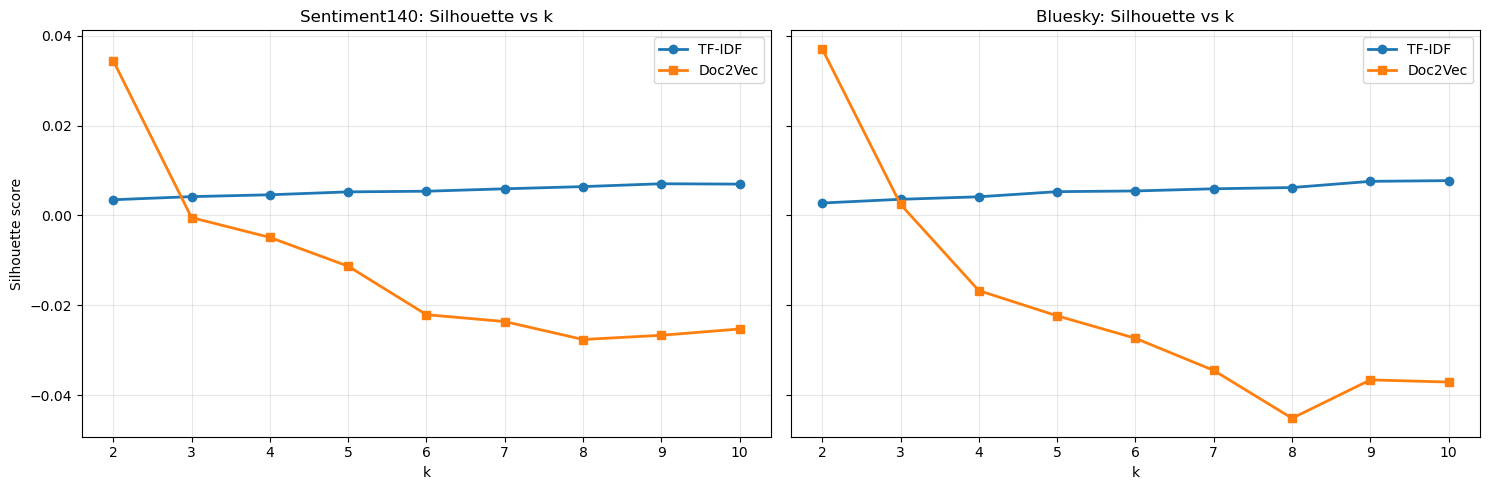


Combined clustering summary:
representation       corpus  best_k  silhouette     ARI      NMI
        TF-IDF Sentiment140       9    0.007036 0.00561 0.017363
        TF-IDF      Bluesky      10    0.007734     NaN      NaN
       Doc2Vec Sentiment140       2    0.034434 0.00176 0.001282
       Doc2Vec      Bluesky       2    0.037075     NaN      NaN


In [15]:
# ============================================================
# Section 3: Doc2Vec Vectorization + K-means Clustering
# ============================================================

import numpy as np
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.utils import simple_preprocess


def build_doc2vec_vectors(
    texts: pd.Series,
    vector_size: int = 200,
    window: int = 5,
    min_count: int = 2,
    epochs: int = 20,
    dm: int = 1,
):
    """Train Doc2Vec on a corpus and return inferred document vectors plus the model."""
    tokenized_texts = [simple_preprocess(str(text), deacc=False, min_len=1) for text in texts]
    tagged_docs = [TaggedDocument(words=tokens, tags=[idx]) for idx, tokens in enumerate(tokenized_texts)]

    model = Doc2Vec(
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        dm=dm,
        seed=RANDOM_STATE,
        workers=1,
        epochs=epochs,
    )
    model.build_vocab(tagged_docs)
    model.train(tagged_docs, total_examples=model.corpus_count, epochs=epochs)

    vectors = np.vstack([
        model.infer_vector(tokens, epochs=epochs) for tokens in tokenized_texts
    ]).astype(np.float32)
    return vectors, model


def sweep_kmeans_silhouette_from_dense(X, k_values=range(2, 11), sample_size=10_000):
    """Run the same K-means + silhouette sweep on dense document vectors."""
    results = []
    best_model = None
    best_k = None
    best_score = -1.0

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels, sample_size=sample_size, random_state=RANDOM_STATE)
        results.append({"k": k, "silhouette": score})
        print(f"k={k}: silhouette={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_model = model

    results_df = pd.DataFrame(results)
    return results_df, best_k, best_score, best_model


print("Preparing corpora for Doc2Vec...")
s140_doc2vec_input = s140_clean[["text_clean", "label"]].copy()
bsky_doc2vec_input = bsky_clean[["text_clean"]].copy()

print("Training Doc2Vec on Sentiment140...")
X_s140_doc2vec, s140_doc2vec_model = build_doc2vec_vectors(
    s140_doc2vec_input["text_clean"],
    vector_size=200,
    window=5,
    min_count=2,
    epochs=20,
    dm=1,
)
print(f"Sentiment140 Doc2Vec shape: {X_s140_doc2vec.shape}")

print("Training Doc2Vec on Bluesky...")
X_bsky_doc2vec, bsky_doc2vec_model = build_doc2vec_vectors(
    bsky_doc2vec_input["text_clean"],
    vector_size=200,
    window=5,
    min_count=2,
    epochs=20,
    dm=1,
)
print(f"Bluesky Doc2Vec shape: {X_bsky_doc2vec.shape}")

print("\nRunning K-means sweep on Sentiment140 Doc2Vec vectors...")
s140_d2v_results, s140_d2v_best_k, s140_d2v_best_silhouette, s140_d2v_best_model = sweep_kmeans_silhouette_from_dense(X_s140_doc2vec)

print("\nRunning K-means sweep on Bluesky Doc2Vec vectors...")
bsky_d2v_results, bsky_d2v_best_k, bsky_d2v_best_silhouette, bsky_d2v_best_model = sweep_kmeans_silhouette_from_dense(X_bsky_doc2vec)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

axes[0].plot(s140_results["k"], s140_results["silhouette"], marker="o", linewidth=2, label="TF-IDF")
axes[0].plot(s140_d2v_results["k"], s140_d2v_results["silhouette"], marker="s", linewidth=2, label="Doc2Vec")
axes[0].set_title("Sentiment140: Silhouette vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette score")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(bsky_results["k"], bsky_results["silhouette"], marker="o", linewidth=2, label="TF-IDF")
axes[1].plot(bsky_d2v_results["k"], bsky_d2v_results["silhouette"], marker="s", linewidth=2, label="Doc2Vec")
axes[1].set_title("Bluesky: Silhouette vs k")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

s140_d2v_labels = s140_d2v_best_model.labels_
s140_d2v_ari = adjusted_rand_score(s140_doc2vec_input["label"], s140_d2v_labels)
s140_d2v_nmi = normalized_mutual_info_score(s140_doc2vec_input["label"], s140_d2v_labels)

tfidf_summary = pd.DataFrame(
    [
        {
            "representation": "TF-IDF",
            "corpus": "Sentiment140",
            "best_k": s140_best_k,
            "silhouette": s140_best_silhouette,
            "ARI": s140_ari,
            "NMI": s140_nmi,
        },
        {
            "representation": "TF-IDF",
            "corpus": "Bluesky",
            "best_k": bsky_best_k,
            "silhouette": bsky_best_silhouette,
            "ARI": None,
            "NMI": None,
        },
    ]
)

doc2vec_summary = pd.DataFrame(
    [
        {
            "representation": "Doc2Vec",
            "corpus": "Sentiment140",
            "best_k": s140_d2v_best_k,
            "silhouette": s140_d2v_best_silhouette,
            "ARI": s140_d2v_ari,
            "NMI": s140_d2v_nmi,
        },
        {
            "representation": "Doc2Vec",
            "corpus": "Bluesky",
            "best_k": bsky_d2v_best_k,
            "silhouette": bsky_d2v_best_silhouette,
            "ARI": None,
            "NMI": None,
        },
    ]
)

summary = pd.concat([tfidf_summary, doc2vec_summary], ignore_index=True)
summary = summary[["representation", "corpus", "best_k", "silhouette", "ARI", "NMI"]]

print("\nCombined clustering summary:")
print(summary.to_string(index=False))


s140: 99,822 rows | bsky: 99,556 rows

Loading SBERT model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 26040.59it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Encoding Sentiment140 with SBERT (this takes ~10-20 mins on CPU)...


Batches: 100%|██████████| 390/390 [00:22<00:00, 17.38it/s]


Sentiment140 SBERT shape: (99822, 384)

Encoding Bluesky with SBERT...


Batches: 100%|██████████| 389/389 [00:25<00:00, 15.29it/s]


Bluesky SBERT shape: (99556, 384)

Running K-means sweep on Sentiment140 SBERT embeddings...
  k=2: silhouette=0.0182
  k=3: silhouette=0.0186
  k=4: silhouette=0.0113
  k=5: silhouette=0.0118
  k=6: silhouette=0.0127
  k=7: silhouette=0.0137
  k=8: silhouette=0.0147
  k=9: silhouette=0.0156
  k=10: silhouette=0.0167

Running K-means sweep on Bluesky SBERT embeddings...
  k=2: silhouette=0.0233
  k=3: silhouette=0.0166
  k=4: silhouette=0.0166
  k=5: silhouette=0.0137
  k=6: silhouette=0.0147
  k=7: silhouette=0.0128
  k=8: silhouette=0.0138
  k=9: silhouette=0.0124
  k=10: silhouette=0.0129

Updated clustering summary:
representation       corpus best_k  silhouette      ARI      NMI
         SBERT Sentiment140      3    0.018554 0.002201 0.002241
         SBERT      Bluesky      2    0.023252      NaN      NaN


/var/folders/17/lphw45ds14n5t74zwjdfybx40000gn/T/ipykernel_9602/988025993.py:97: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([prior_summary, sbert_rows], ignore_index=True).drop_duplicates(


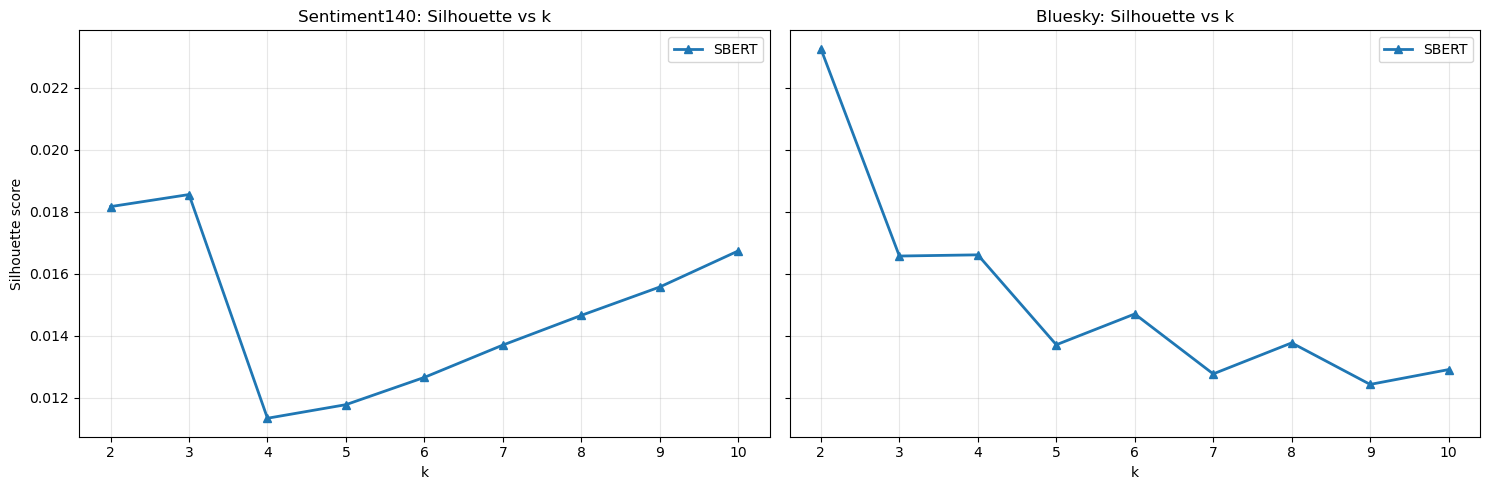

In [3]:
# ============================================================
# Section 4: Sentence-BERT Embeddings + K-means Clustering
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sentence_transformers import SentenceTransformer

# ── Reload corpora ───────────────────────────────────────────
s140_clean = pd.read_csv("s140_clean.csv")
bsky_clean  = pd.read_csv("bsky_clean.csv")
print(f"s140: {len(s140_clean):,} rows | bsky: {len(bsky_clean):,} rows")

# ── Reload prior results so the combined plot works ──────────
# These CSVs get saved at the bottom of this cell — on first run
# they won't exist yet, so we guard with a try/except
try:
    prior_summary = pd.read_csv("clustering_summary.csv")
except FileNotFoundError:
    prior_summary = pd.DataFrame(columns=["representation", "corpus", "best_k", "silhouette", "ARI", "NMI"])

try:
    s140_tfidf_results = pd.read_csv("s140_tfidf_results.csv")
    bsky_tfidf_results = pd.read_csv("bsky_tfidf_results.csv")
    s140_d2v_results   = pd.read_csv("s140_d2v_results.csv")
    bsky_d2v_results   = pd.read_csv("bsky_d2v_results.csv")
    have_prior_curves  = True
except FileNotFoundError:
    have_prior_curves  = False
    print("Warning: prior silhouette curve CSVs not found — plot will show SBERT only.")

# ── Helper: K-means sweep on dense matrix ────────────────────
def sweep_kmeans_dense(X: np.ndarray, k_range=range(2, 11), seed: int = 42):
    """
    Run K-means for each k, score with silhouette.
    Returns (results_df, best_k, best_silhouette, best_model).
    """
    records = []
    best_score, best_k, best_model = -999, 2, None
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        score  = silhouette_score(X, labels, sample_size=10_000, random_state=seed)
        print(f"  k={k}: silhouette={score:.4f}")
        records.append({"k": k, "silhouette": score})
        if score > best_score:
            best_score, best_k, best_model = score, k, km
    return pd.DataFrame(records), best_k, best_score, best_model

# ── Load SBERT model ─────────────────────────────────────────
print("\nLoading SBERT model...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

# ── Encode corpora ───────────────────────────────────────────
def encode_sbert(texts: pd.Series, model: SentenceTransformer, batch_size: int = 256) -> np.ndarray:
    return model.encode(
        texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )

print("\nEncoding Sentiment140 with SBERT (this takes ~10-20 mins on CPU)...")
X_s140_sbert = encode_sbert(s140_clean["text_clean"], sbert_model)
print(f"Sentiment140 SBERT shape: {X_s140_sbert.shape}")

print("\nEncoding Bluesky with SBERT...")
X_bsky_sbert = encode_sbert(bsky_clean["text_clean"], sbert_model)
print(f"Bluesky SBERT shape: {X_bsky_sbert.shape}")

# ── K-means sweep ────────────────────────────────────────────
print("\nRunning K-means sweep on Sentiment140 SBERT embeddings...")
s140_sbert_results, s140_sbert_best_k, s140_sbert_best_sil, s140_sbert_best_model = sweep_kmeans_dense(X_s140_sbert)

print("\nRunning K-means sweep on Bluesky SBERT embeddings...")
bsky_sbert_results, bsky_sbert_best_k, bsky_sbert_best_sil, bsky_sbert_best_model = sweep_kmeans_dense(X_bsky_sbert)

# ── ARI / NMI on Sentiment140 ────────────────────────────────
s140_sbert_labels = s140_sbert_best_model.labels_
s140_sbert_ari = adjusted_rand_score(s140_clean["label"], s140_sbert_labels)
s140_sbert_nmi = normalized_mutual_info_score(s140_clean["label"], s140_sbert_labels)

# ── Combined summary table ───────────────────────────────────
sbert_rows = pd.DataFrame([
    {"representation": "SBERT", "corpus": "Sentiment140",
     "best_k": s140_sbert_best_k, "silhouette": s140_sbert_best_sil,
     "ARI": s140_sbert_ari, "NMI": s140_sbert_nmi},
    {"representation": "SBERT", "corpus": "Bluesky",
     "best_k": bsky_sbert_best_k, "silhouette": bsky_sbert_best_sil,
     "ARI": None, "NMI": None},
])

summary = pd.concat([prior_summary, sbert_rows], ignore_index=True).drop_duplicates(
    subset=["representation", "corpus"], keep="last"
)
summary = summary[["representation", "corpus", "best_k", "silhouette", "ARI", "NMI"]]
print("\nUpdated clustering summary:")
print(summary.to_string(index=False))
summary.to_csv("clustering_summary.csv", index=False)

# ── Silhouette vs k plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, corpus, sbert_res in [
    (axes[0], "Sentiment140", s140_sbert_results),
    (axes[1], "Bluesky",      bsky_sbert_results),
]:
    if have_prior_curves:
        tfidf_res = s140_tfidf_results if corpus == "Sentiment140" else bsky_tfidf_results
        d2v_res   = s140_d2v_results   if corpus == "Sentiment140" else bsky_d2v_results
        ax.plot(tfidf_res["k"], tfidf_res["silhouette"], marker="o", linewidth=2, label="TF-IDF")
        ax.plot(d2v_res["k"],   d2v_res["silhouette"],   marker="s", linewidth=2, label="Doc2Vec")
    ax.plot(sbert_res["k"], sbert_res["silhouette"], marker="^", linewidth=2, label="SBERT")
    ax.set_title(f"{corpus}: Silhouette vs k")
    ax.set_xlabel("k")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Section 5: LDA Topic Modeling + Coherence Selection
# ============================================================

import numpy as np
import pandas as pd
from collections import defaultdict
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from gensim.utils import simple_preprocess
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

RANDOM_STATE = 42
LDA_PARAMS = {
    "max_features": 20_000,
    "min_df": 3,
    "max_df": 0.95,
}


def load_lda_corpus(path: str, label_col: str | None = None) -> pd.DataFrame:
    """Load a cleaned corpus for LDA."""
    df = pd.read_csv(path)
    required_cols = ["text_clean"] + ([label_col] if label_col is not None else [])
    df = df.dropna(subset=required_cols).reset_index(drop=True)
    df["text_clean"] = df["text_clean"].astype(str)
    if label_col is not None:
        df[label_col] = df[label_col].astype(int)
    return df


def tokenize_texts(texts: pd.Series):
    """Tokenize documents for coherence computation."""
    return [simple_preprocess(text, deacc=False, min_len=1) for text in texts]


def topic_words_from_lda(model: LatentDirichletAllocation, feature_names, top_n: int = 10):
    """Extract the top-N words per topic from a fitted sklearn LDA model."""
    topics = []
    for topic_weights in model.components_:
        top_indices = topic_weights.argsort()[-top_n:][::-1]
        topics.append([feature_names[index] for index in top_indices])
    return topics


def fit_lda_with_coherence(texts: pd.Series, topic_values=range(5, 31, 5), seed: int = 42):
    """Fit CountVectorizer + sklearn LDA for several topic counts and score c_v coherence."""
    vectorizer = CountVectorizer(**LDA_PARAMS)
    counts = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    tokenized_texts = tokenize_texts(texts)
    dictionary = Dictionary(tokenized_texts)

    records = []
    best_model = None
    best_topics = None
    best_n_topics = None
    best_coherence = -np.inf

    for n_topics in topic_values:
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=seed,
            learning_method="batch",
        )
        lda.fit(counts)
        topics = topic_words_from_lda(lda, feature_names, top_n=10)
        coherence_model = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence="c_v",
        )
        coherence = coherence_model.get_coherence()
        records.append({"n_topics": n_topics, "coherence": coherence})
        print(f"n_topics={n_topics}: c_v coherence={coherence:.4f}")

        if coherence > best_coherence:
            best_coherence = coherence
            best_model = lda
            best_topics = topics
            best_n_topics = n_topics

    results_df = pd.DataFrame(records)
    return results_df, best_n_topics, best_coherence, best_model, best_topics, vectorizer


def print_topic_keywords(topics, corpus_name: str):
    """Print the top keywords for each topic in a fitted LDA model."""
    print(f"\nTop 10 keywords per topic for {corpus_name}:")
    for topic_idx, words in enumerate(topics, start=1):
        print(f"Topic {topic_idx:02d}: {', '.join(words)}")


print("Loading cleaned corpora for LDA...")
s140_lda = load_lda_corpus("s140_clean.csv", label_col="label")
bsky_lda = load_lda_corpus("bsky_clean.csv")

print(f"Sentiment140 rows: {len(s140_lda):,}")
print(f"Bluesky rows: {len(bsky_lda):,}")

print("\nSweeping LDA topic counts for Sentiment140...")
s140_lda_results, s140_lda_best_n, s140_lda_best_coherence, s140_lda_best_model, s140_lda_best_topics, s140_lda_vectorizer = fit_lda_with_coherence(
    s140_lda["text_clean"],
    topic_values=range(5, 31, 5),
    seed=RANDOM_STATE,
 )

print("\nSweeping LDA topic counts for Bluesky...")
bsky_lda_results, bsky_lda_best_n, bsky_lda_best_coherence, bsky_lda_best_model, bsky_lda_best_topics, bsky_lda_vectorizer = fit_lda_with_coherence(
    bsky_lda["text_clean"],
    topic_values=range(5, 31, 5),
    seed=RANDOM_STATE,
 )

print_topic_keywords(s140_lda_best_topics, "Sentiment140")
print_topic_keywords(bsky_lda_best_topics, "Bluesky")

lda_coherence_table = pd.DataFrame([
    {"corpus": "Sentiment140", "best_n_topics": s140_lda_best_n, "coherence_c_v": s140_lda_best_coherence},
    {"corpus": "Bluesky", "best_n_topics": bsky_lda_best_n, "coherence_c_v": bsky_lda_best_coherence},
])

print("\nLDA coherence summary:")
print(lda_coherence_table.to_string(index=False))

print("\nAll topic-count coherence scores:")
lda_all_scores = pd.concat([
    s140_lda_results.assign(corpus="Sentiment140"),
    bsky_lda_results.assign(corpus="Bluesky"),
])[["corpus", "n_topics", "coherence"]]
print(lda_all_scores.to_string(index=False))


Loading cleaned corpora for LDA...
Sentiment140 rows: 99,822
Bluesky rows: 99,556

Sweeping LDA topic counts for Sentiment140...
n_topics=5: c_v coherence=0.4809
n_topics=10: c_v coherence=0.4746
n_topics=15: c_v coherence=0.4751
n_topics=20: c_v coherence=0.4739
n_topics=25: c_v coherence=0.4817
n_topics=30: c_v coherence=0.4896

Sweeping LDA topic counts for Bluesky...
n_topics=5: c_v coherence=0.6072
n_topics=10: c_v coherence=0.6163
n_topics=15: c_v coherence=0.5988
n_topics=20: c_v coherence=0.6075
n_topics=25: c_v coherence=0.6111
n_topics=30: c_v coherence=0.5939

Top 10 keywords per topic for Sentiment140:
Topic 01: been, fun, have, ve, no, has, this, on, in, since
Topic 02: more, they, that, me, people, are, to, them, like, of
Topic 03: what, not, it, do, to, but, that, have, out, or
Topic 04: back, days, from, just, already, got, home, lol, bored, and
Topic 05: you, love, re, haha, to, so, guys, in, are, that
Topic 06: my, now, on, right, im, and, is, just, finally, new
Topic

Loading cleaned corpora for VADER...
Scoring Sentiment140 with VADER...
Scoring Bluesky with VADER...

VADER baseline metrics (Sentiment140):
     dataset                           threshold_rule  evaluated_rows  precision   recall       f1
Sentiment140 compound >= 0.05 => pos, <= -0.05 => neg           73126   0.661671 0.864297 0.749531

Dropped neutral rows: 26.74% of Sentiment140


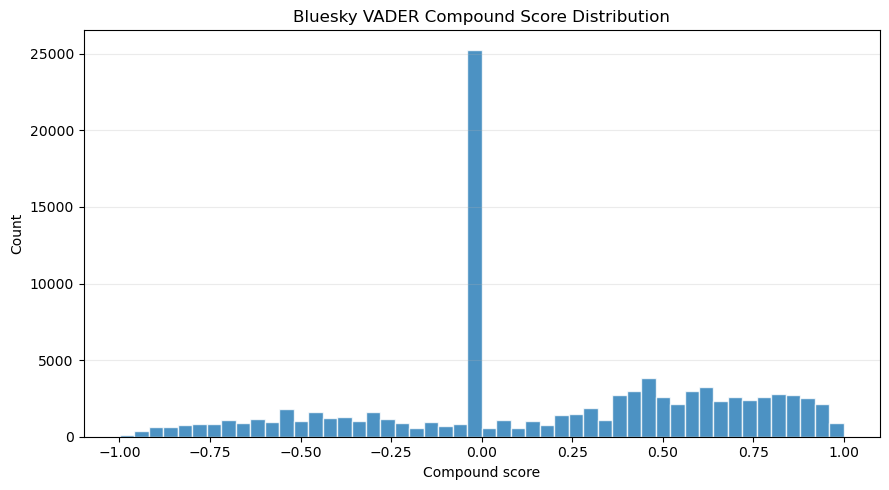

In [3]:
# ============================================================
# Section 6: VADER Sentiment Baseline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

RANDOM_STATE = 42


def load_vader_corpus(path: str, label_col: str | None = None) -> pd.DataFrame:
    """Load cleaned corpora for VADER sentiment scoring."""
    df = pd.read_csv(path)
    required_cols = ["text_clean"] + ([label_col] if label_col is not None else [])
    df = df.dropna(subset=required_cols).reset_index(drop=True)
    df["text_clean"] = df["text_clean"].astype(str)
    if label_col is not None:
        df[label_col] = df[label_col].astype(int)
    return df


def vader_compound_scores(texts: pd.Series, analyzer: SentimentIntensityAnalyzer) -> pd.Series:
    """Compute VADER compound score for each text."""
    return texts.apply(lambda x: analyzer.polarity_scores(x)["compound"])


def vader_label_from_compound(score: float):
    """Map compound score to binary sentiment with neutral zone."""
    if score >= 0.05:
        return 1
    if score <= -0.05:
        return 0
    return np.nan


print("Loading cleaned corpora for VADER...")
s140_vader = load_vader_corpus("s140_clean.csv", label_col="label")
bsky_vader = load_vader_corpus("bsky_clean.csv")

analyzer = SentimentIntensityAnalyzer()

print("Scoring Sentiment140 with VADER...")
s140_vader["compound"] = vader_compound_scores(s140_vader["text_clean"], analyzer)
s140_vader["pred_label"] = s140_vader["compound"].apply(vader_label_from_compound)

print("Scoring Bluesky with VADER...")
bsky_vader["compound"] = vader_compound_scores(bsky_vader["text_clean"], analyzer)

# Drop neutrals for Sentiment140 evaluation as requested
s140_eval = s140_vader.dropna(subset=["pred_label"]).copy()
s140_eval["pred_label"] = s140_eval["pred_label"].astype(int)

precision = precision_score(s140_eval["label"], s140_eval["pred_label"])
recall = recall_score(s140_eval["label"], s140_eval["pred_label"])
f1 = f1_score(s140_eval["label"], s140_eval["pred_label"])

metrics_table = pd.DataFrame([
    {
        "dataset": "Sentiment140",
        "threshold_rule": "compound >= 0.05 => pos, <= -0.05 => neg",
        "evaluated_rows": len(s140_eval),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }
])

print("\nVADER baseline metrics (Sentiment140):")
print(metrics_table.to_string(index=False))

neutral_rate = 1 - (len(s140_eval) / len(s140_vader))
print(f"\nDropped neutral rows: {neutral_rate:.2%} of Sentiment140")

plt.figure(figsize=(9, 5))
plt.hist(bsky_vader["compound"], bins=50, color="tab:blue", alpha=0.8, edgecolor="white")
plt.title("Bluesky VADER Compound Score Distribution")
plt.xlabel("Compound score")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()